# Tesla Stock Opening Price Prediction using ARIMA and LSTM
## Comparative Analysis of Statistical and Deep Learning Models

## 1. Import Required Libraries

In [2]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

## 2. Data Acquisition and Loading

In [3]:
df=pd.read_csv(r'C:\Users\ashld\Downloads\archive\TSLA.csv')

In [4]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


## 3. Data Preprocessing

In [5]:
df['Date']=pd.to_datetime(df['Date'])

In [6]:
df.set_index('Date',inplace=True)

In [7]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


## 4. Exploratory Data Analysis (EDA)

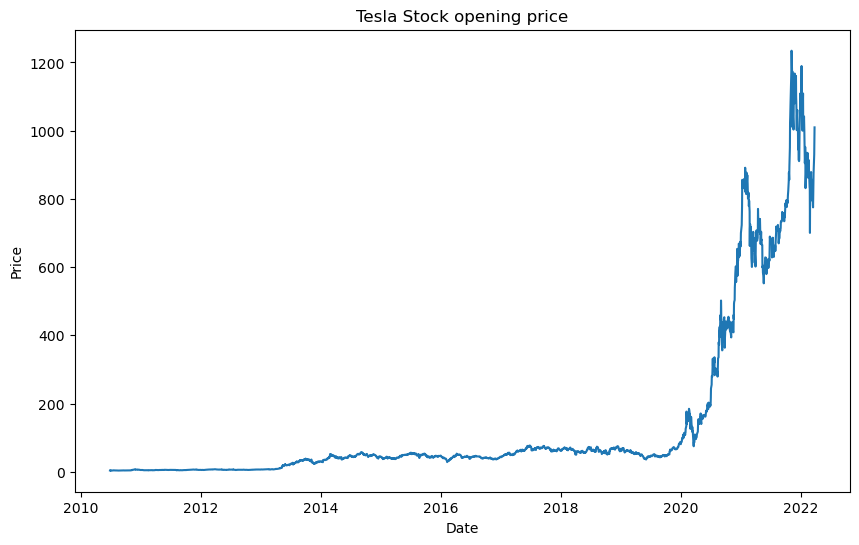

In [8]:
plt.figure(figsize=(10,6))
plt.plot(df['Open'])
plt.title("Tesla Stock opening price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [9]:
print(df.isnull().sum())

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


## 5. Stationarity Analysis(ADF Test)

In [10]:
result=adfuller(df['Open'])
print("ADF Statistics:",result[0])
print("p-value:",result[1])

ADF Statistics: 1.315484494511326
p-value: 0.9966942428805355


### 5.1 First Order Differencing

In [11]:
df_diff=df['Open'].diff().dropna()

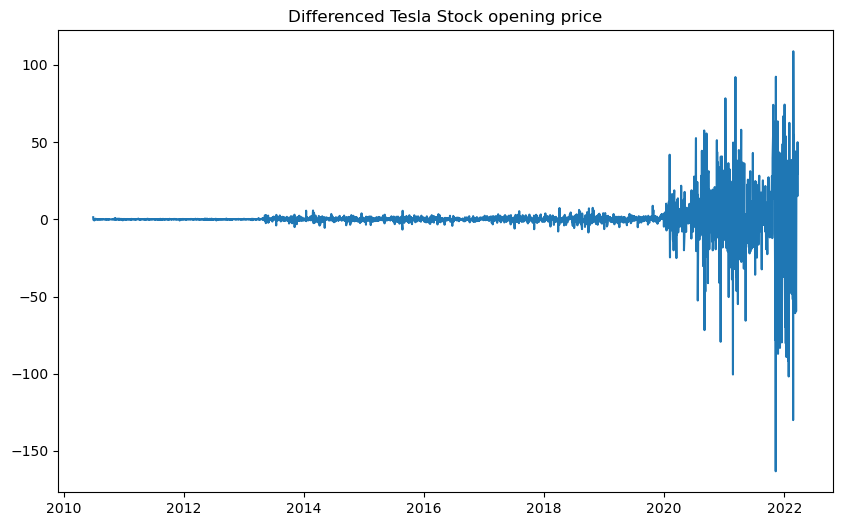

In [12]:
plt.figure(figsize=(10,6))
plt.plot(df_diff)
plt.title("Differenced Tesla Stock opening price")
plt.show()

In [13]:
result=adfuller(df_diff)
print("ADF Statistics:",result[0])
print("p-value:",result[1])

ADF Statistics: -9.994223279327768
p-value: 1.9595420065880433e-17


## 6. ACF and PACF analysis

<Figure size 1000x600 with 0 Axes>

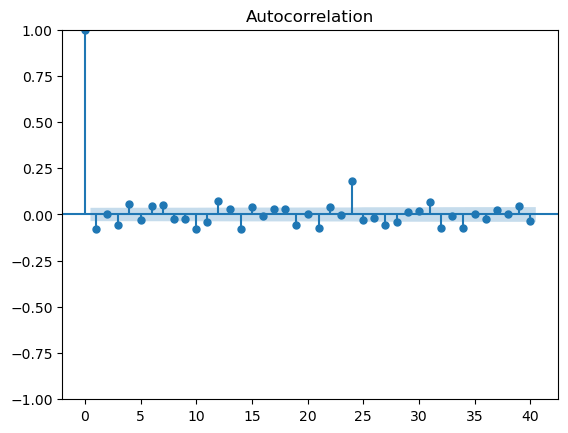

In [14]:
plt.figure(figsize=(10,6))
plot_acf(df_diff,lags=40)
plt.show()

<Figure size 1000x600 with 0 Axes>

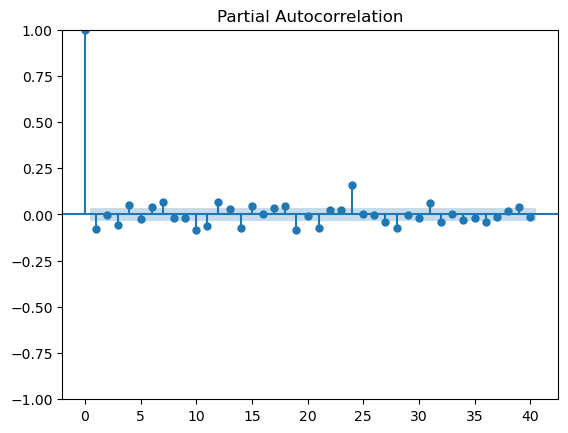

In [15]:
plt.figure(figsize=(10,6))
plot_pacf(df_diff,lags=40)
plt.show()

In [ ]:
best_aic=float('inf')
best_order=None
for p in range(6):
    for d in range(2):
        for q in range(6):
            try:
                model=ARIMA(df['Open'],order=(p,d,q))
                result=model.fit()
                if result.aic < best_aic:
                    best_aic=result.aic
                    best_order=(p,d,q)
            except:
                continue
print("Best Order:",best_order)
print("Best AIC:",best_aic)                    

## 7. ARIMA Modeling and Forecasting

In [17]:
train_size=int(len(df)*0.8)
train=df['Open'][:train_size]
test=df['Open'][train_size:]
print(train.shape)
print(test.shape)

(2364,)
(592,)


In [ ]:
model=ARIMA(train,order=(5,1,4))
result=model.fit()

In [ ]:
forecast=result.forecast(steps=len(test))

In [20]:
forecast.size

592

In [21]:
rmse=np.sqrt(mean_squared_error(test,forecast))
r2=r2_score(test,forecast)
print("RMSE:",rmse)
print("R2:",r2)

RMSE: 573.4746978108438
R2: -2.274963347687817


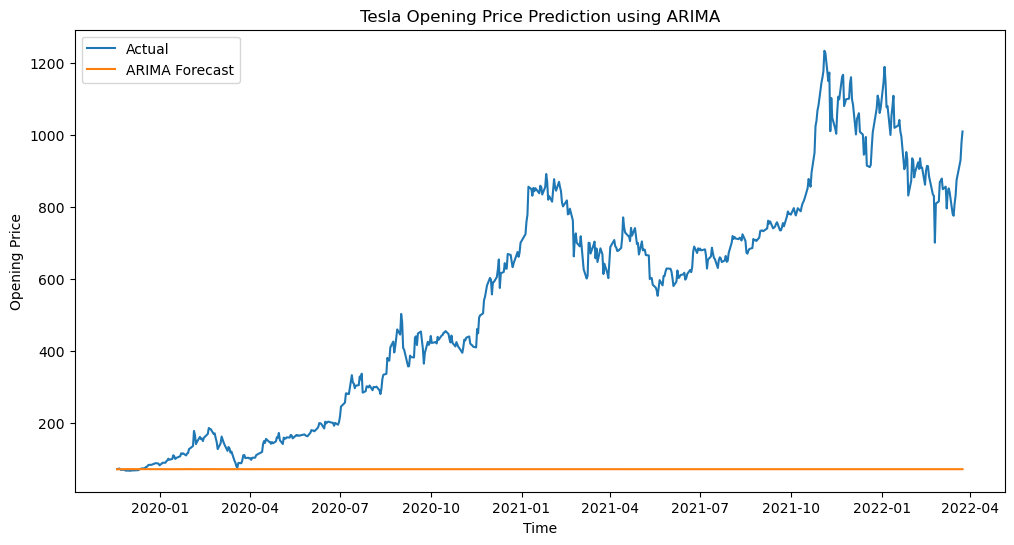

In [22]:
plt.figure(figsize=(12,6))
plt.plot(test.index,test,label="Actual")
plt.plot(test.index,forecast,label="ARIMA Forecast")
plt.title("Tesla Opening Price Prediction using ARIMA")
plt.xlabel("Time")
plt.ylabel("Opening Price")
plt.legend()
plt.show()

## 8. Data Preparation for LSTM

In [23]:
data=df[['Open']]

### 8.1 Min-Max Scaling

In [24]:
scaler=MinMaxScaler(feature_range=(0,1))
data=scaler.fit_transform(data)

In [25]:
print(data[:5])
print(data.shape)

[[0.00046459]
 [0.0015676 ]
 [0.00143927]
 [0.00111438]
 [0.00062704]]
(2956, 1)


### 8.2 Creating 60-day sequencem

In [26]:
X=[]
y=[]
window_size=60
for i in range(window_size,len(data)):
    X.append(data[i-window_size:i,0])
    y.append(data[i,0])
X=np.array(X)
y=np.array(y)

In [27]:
print(X.shape)
print(y.shape)

(2896, 60)
(2896,)


In [28]:
X=X.reshape(X.shape[0],X.shape[1],1)
print(X.shape)

(2896, 60, 1)


### 8.3 Train test split

In [29]:
train_size=int(len(X)*0.8)
X_train=X[:train_size]
X_test=X[train_size:]
y_train=y[:train_size]
y_test=y[train_size:]

## 9. LSTM Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model=Sequential()
model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(60,1)
    )
)
model.add(Dropout(0.2))
model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

In [31]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [32]:
print(tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

2.21.0
GPUs: []


In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Model Training

In [34]:
history=model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test),
    verbose=1
    )

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 1.2811e-04 - val_loss: 0.0033
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 1.1774e-05 - val_loss: 0.0044
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 1.0729e-05 - val_loss: 0.0031
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 9.9520e-06 - val_loss: 0.0047
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 9.3080e-06 - val_loss: 0.0030
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 9.2900e-06 - val_loss: 0.0038
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 8.8324e-06 - val_loss: 0.0025
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 7.3101e-06 - val_loss: 0.0034
Epoch 9/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 1.0443e-05 - val_loss: 0.0033
Epoch 10/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 8.2743e-06 - val_loss: 0.0016
Epoch 11/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 7.3590e-06 - val_loss: 0.0021
Epoch 12/20
73/73 ━

In [35]:
print(history.history.keys())

dict_keys(['loss', 'val_loss'])


In [36]:
print("Final Training Loss:",history.history['loss'][-1])
print("Final Validation Loss:",history.history['val_loss'][-1])

Final Training Loss: 6.4441387621627655e-06
Final Validation Loss: 0.0018356243381276727


## 11. LSTM Predictions and Evaluation

In [37]:
predictions=model.predict(X_test)
predictions=scaler.inverse_transform(predictions)
y_test_actual=scaler.inverse_transform(y_test.reshape(-1,1))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


In [38]:
rmse=np.sqrt(mean_squared_error(y_test_actual,predictions))
r2=r2_score(y_test_actual,predictions)
print("RMSE:",rmse)
print("R2:",r2)

RMSE: 52.74898385760925
R2: 0.9715020395758662


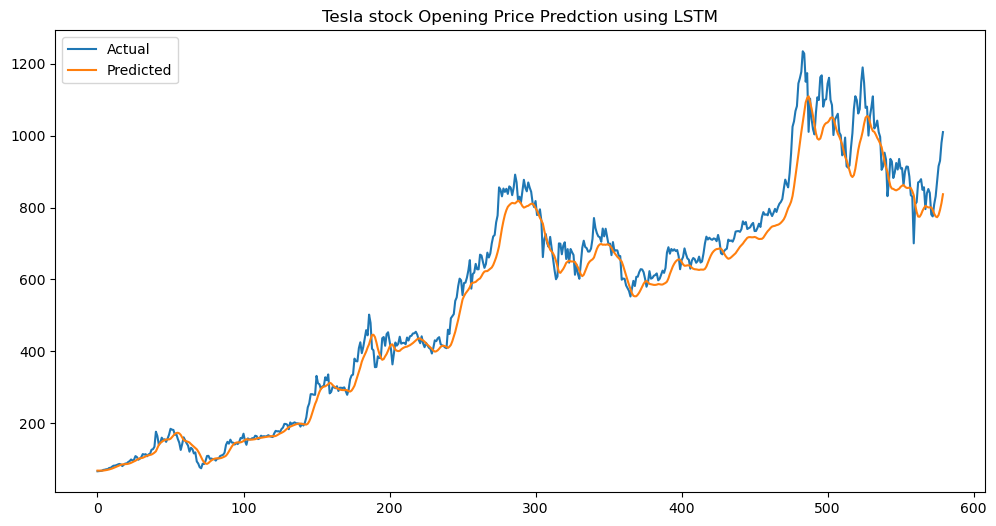

In [39]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual,label="Actual")
plt.plot(predictions,label="Predicted")
plt.title("Tesla stock Opening Price Predction using LSTM")
plt.legend()
plt.show()

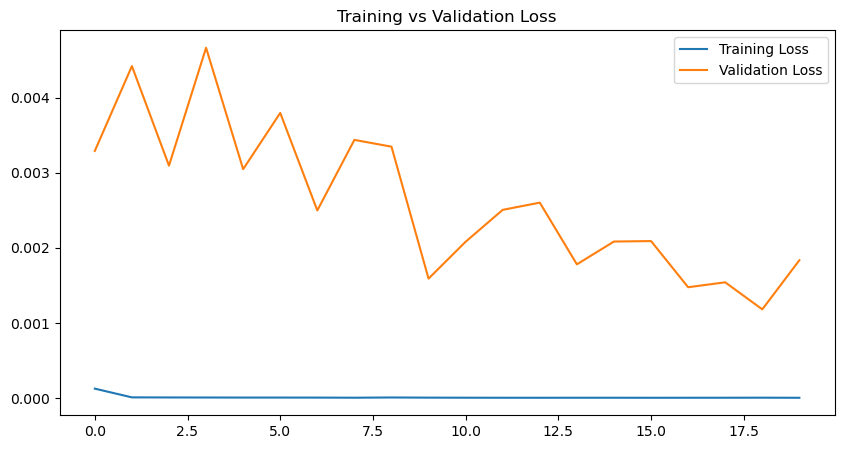

In [40]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [41]:
import nbformat

nb = nbformat.read(
    "Tesla_Stock_Price_Prediction.ipynb",
    as_version=4
)

for cell in nb.cells:
    if cell.cell_type == "code":
        cell.outputs = []
        cell.execution_count = None

nbformat.write(
    nb,
    "Tesla_Stock_Price_Prediction_GitHub.ipynb"
)

print("Done")

Done
